In [2]:
##############
## INITIATE ##
##############

## Imports
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Import modules
from f_dataset_wsi import WSIDatasetByInstance
from f_wsi_reader import slide_path_to_tiles_at_coordinates
from f_wsi_reader import get_tile_map
from f_wsi_reader import slide_to_tiles_at_coordinates
from f_wsi_reader import read_slide
from f_wsi_reader import get_dimensions
from f_wsi_reader import apply_all_filters
from f_wsi_reader import apply_all_transforms
from f_wsi_reader import reassemble_tiles

#
###

In [3]:
###########################
## VISUALIZATION SCRIPT  ##
###########################

## Parameters
wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/PANDA/images/tiff/0a93d9a674e358ba32e4e2ec320aefc5.tiff'] # PANDA
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/TCGA/images/svs/TCGA-EJ-5509-01A_2.svs'] # TCGA
# wsi_paths = ['/Volumes/SED/BDI/databases/RAW/datasets/SEGG/images/test/17_A047-4463_153D+-+2017-05-11+09.40.22_TissueTrain_(1.00,46495,20054,8837,6413)/reference/17_A047-4463_153D+-+2017-05-11+09.40.22_TissueTrain_(1.00,46495,20054,8837,6413).png'] # SEGG

#
###

(3328, 25088)


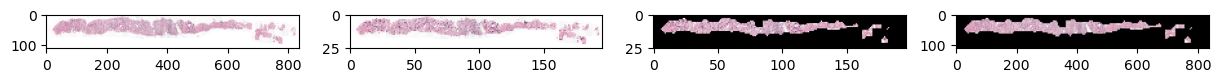

In [4]:
################## 
## GET TILE MAP ##
################## 

## Open slide
slide = read_slide(wsi_paths[0])
slide_size = get_dimensions(slide)
print(slide_size)

## Parameters
tile_size = 128

## Get tile_map
thumbnail, tile_map, canvas_size = get_tile_map(slide, tile_size)

## Extract coordinates of pixels in tile_map that contain tissue
mask = apply_all_filters(tile_map, low=10, std=15, high=200)
mask = apply_all_transforms(mask)

## Get coordinates of tiles with tissue
tile_coordinates = (np.argwhere(mask[:,:,0].T > 0) * tile_size).astype(int)
tile_coordinates = [[tile_coordinate[0], tile_coordinate[1]] for tile_coordinate in tile_coordinates]

## Compute mask
tile_map_masked = tile_map * mask
thumbnail_masked = thumbnail * cv2.resize(mask, (thumbnail.shape[1], thumbnail.shape[0]), cv2.INTER_LINEAR)[:,:,None]
tissue_mask = cv2.resize(mask, (slide_size[1], slide_size[0]), cv2.INTER_LINEAR)[:,:,None]

## Visualise mask
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(thumbnail)
axes[1].imshow(tile_map)
axes[2].imshow(tile_map_masked)
axes[3].imshow(thumbnail_masked)
plt.show()
plt.close()

#
###

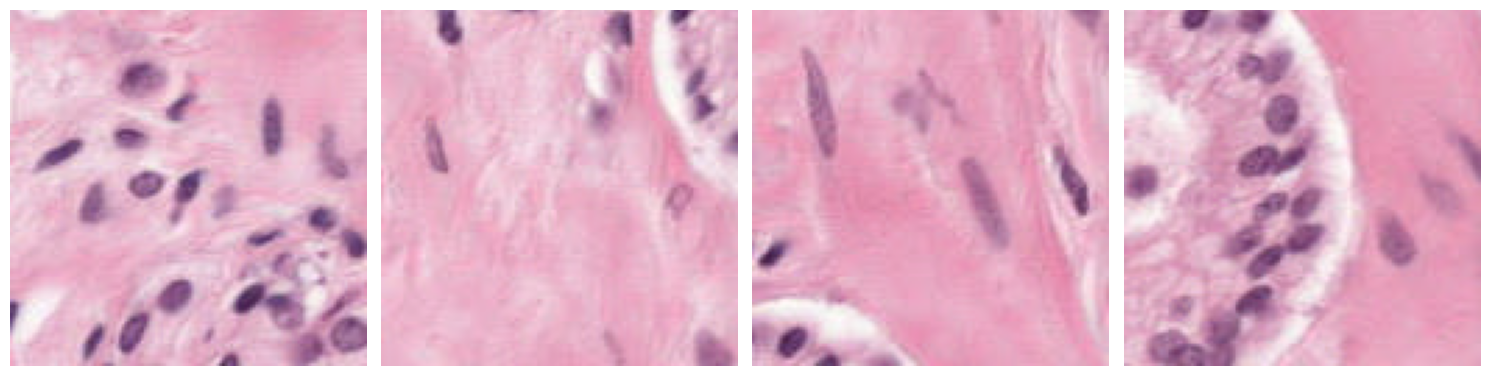

In [5]:
######################
## PATCH EXTRACTION ##
######################

## Parameters
level = 0
ds = 1
if level > 0: 
    ds = 4 * level
tile_size_ = int(tile_size/ds)# + 64
# tile_size_ = 1024

## Load patches from the dataset
patches = slide_path_to_tiles_at_coordinates(wsi_paths[0], tile_coordinates, tile_size_, level) # [dataset[i] for i in range(min(num_patches_to_display, len(dataset)))]

## Display the patches
num_patches_to_display = 4
fig, axes = plt.subplots(1, num_patches_to_display, figsize=(15, 5))
for i, ax in enumerate(axes.flat):
    if i < len(patches):
        ax.imshow(patches[i])
        ax.axis('off')
    else:
        ax.axis('off')  # Hide unused subplots if any
plt.tight_layout()
plt.show()

#
###

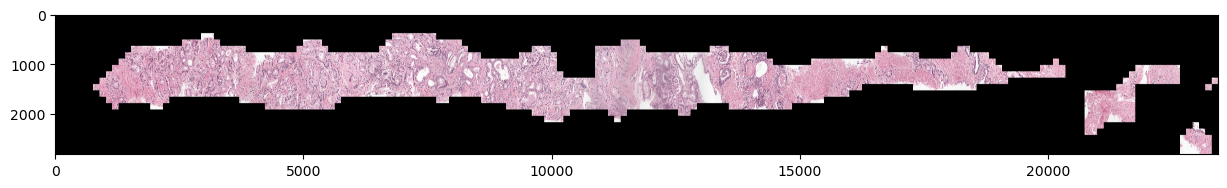

In [32]:
######################
## REASSEMBLE IMAGE ##
######################

## Convert coordinates
ds = 1
if level > 0: 
    ds = 4 * level
tile_coordinates_ds = [[int(coords_[0]/ds), int(coords_[1]/ds)] for coords_ in tile_coordinates]

## Reassemble image
img = reassemble_tiles(patches, tile_coordinates_ds, canvas_size[0], canvas_size[1])

## Visualise
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(img)
# axes[1].axis('off')
# axes[2].axis('off')
# axes[3].axis('off')
plt.show()
plt.close()

#
###

In [16]:
#################
## APPLY MODEL ##
#################

## Imports
import numpy as np
import os
import cv2
import torch
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Import modules
# from f_dataset import SegmentationDataset

## Parameters
# batch_size = 1

## Create dataset and dataloader
# dataset = SegmentationDataset(path_to_dataset, thresholds, transform=None)
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

## Models
# from f_model import UNet as Model
# pt_model_in = 'models/r10_3.pth'
# num_classes = 4
from f_model_transformer import UNetTransformer as Model
pt_model_in = 'models/TransUNet_V2_0.pth'
num_classes = 3

## Load model
device = "mps"
print(f"Using {device} device")
model = Model(n_classes=num_classes).to(device)
if os.path.exists(pt_model_in):
    model.load_state_dict(torch.load(pt_model_in))
    print("Loaded model")

def numpy_to_device(X):
    tensors = []
    for x in X:        
        x = cv2.resize(x, (1024, 1024))        
        x = torch.tensor(x)        
        x = x.swapaxes(2, 1).swapaxes(1, 0) # (H, W, C) --> (C, H, W)
        x = x.float()
        x = x[None, :, :, :] # (C, H, W) --> (B=1, C, H, W)
        x = x.to(device)
        tensors += [x]        
    return tensors

def device_to_numpy(X):
    images = []
    for x in X:
        x = x.cpu().numpy()
        x = x.swapaxes(0, 1).swapaxes(1, 2)    
        x = x.astype('uint8')
        x = cv2.resize(x, (tile_size_, tile_size_))
        images += [x]        
    return images

## Example of iterating through the DataLoader
preds = []
k = 0
X = numpy_to_device(patches)
with torch.no_grad():
    for x in X:                
        Yhat = model(x)        
        Yhat = torch.sigmoid(Yhat) * 255 # Logits to probabilities to [0, 255]        
        Yhat = device_to_numpy(Yhat)[0] # Only for single ptch
        Yhat = np.argmax(Yhat, axis=2).reshape(Yhat.shape[0], Yhat.shape[1], 1) # Only for multiple classes
        preds += [Yhat]        

#
###

Using mps device
Loaded model


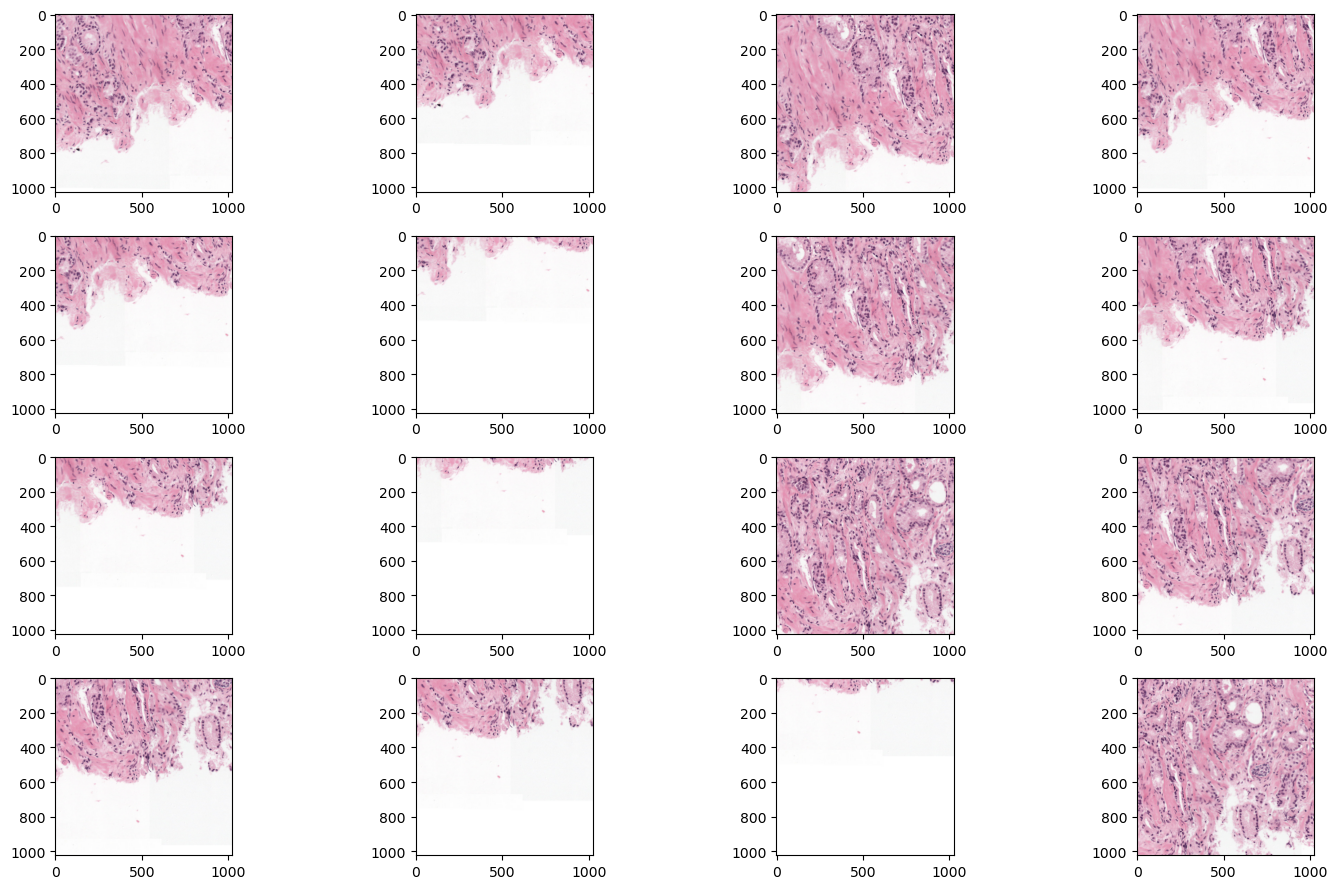

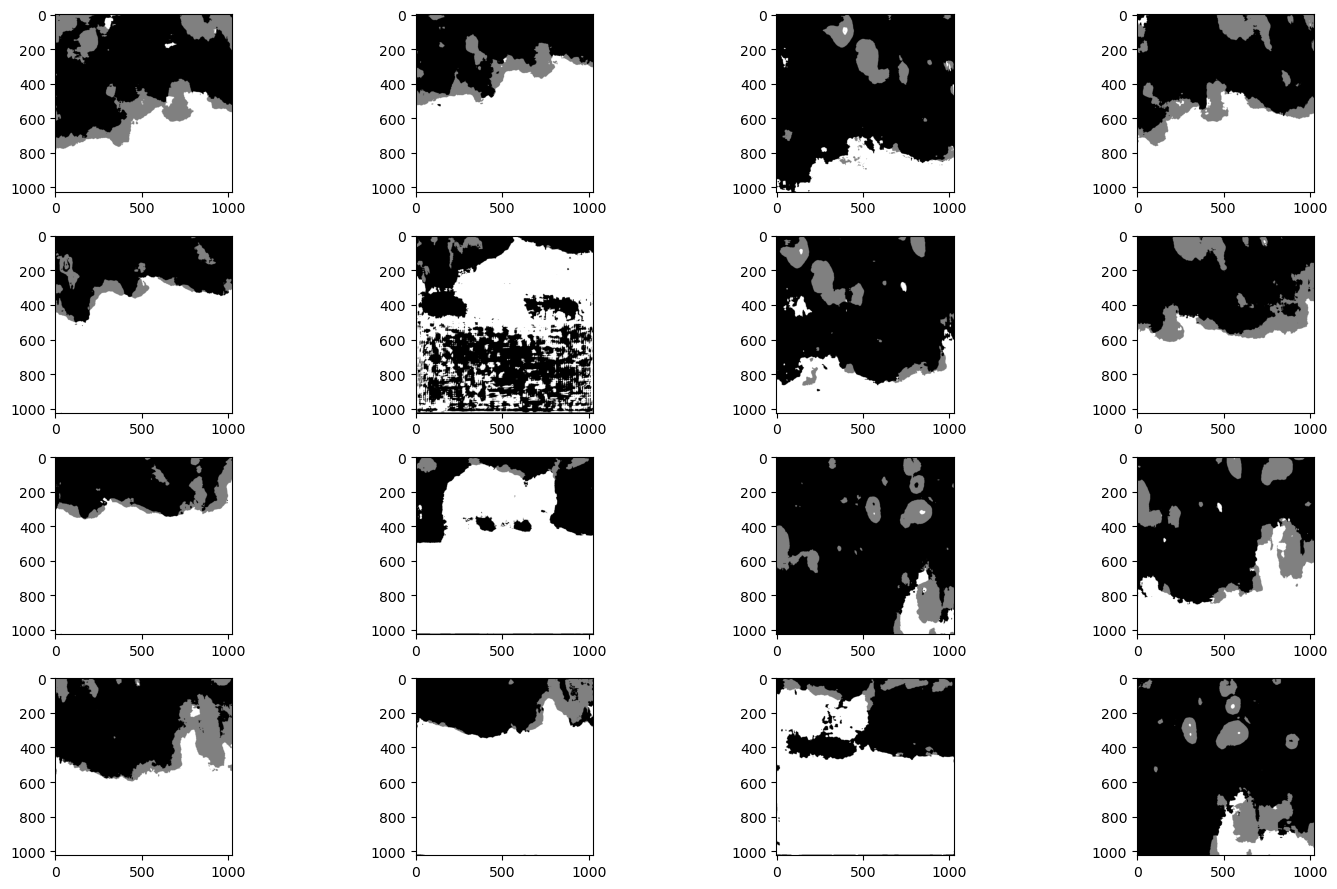

In [26]:
###########################
## VISUALISE PREDICTIONS ##
###########################

## Graphical parameters
from matplotlib.colors import ListedColormap
custom_cmap = 'gist_gray' # ListedColormap(['pink', 'hotpink', 'ivory'])

## Visualise image
fig, axes = plt.subplots(4, 4, figsize=(15,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]        
        axis.imshow(patches[k], cmap=custom_cmap)
        k += 1
plt.tight_layout()
plt.show()
plt.close()

## Visualise predictions
fig, axes = plt.subplots(4, 4, figsize=(15,9))
k = 0
for i in range(4):
    for j in range(4):
        axis = axes[i,j]
        axis.imshow(preds[k], cmap=custom_cmap)        
        k += 1
plt.tight_layout()
plt.show()
plt.close()

#
###

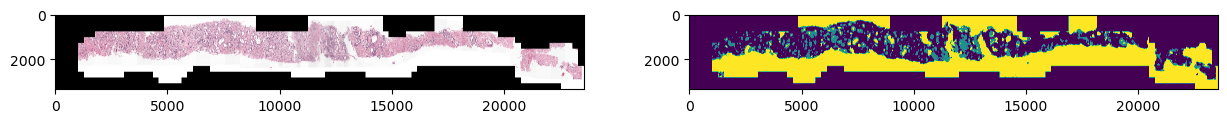

In [27]:
############################
## REASSEMBLE PREDICTIONS ##
############################

## Assemble predictions
img = reassemble_tiles(patches, tile_coordinates)
mask = reassemble_tiles(preds, tile_coordinates)
mask = mask[:,:,0].reshape(mask.shape[0], mask.shape[1], 1)

## Visualise
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(img)
axes[1].imshow(mask)
# axes[2].axis('off')
# axes[3].axis('off')
plt.show()
plt.close()

#
###

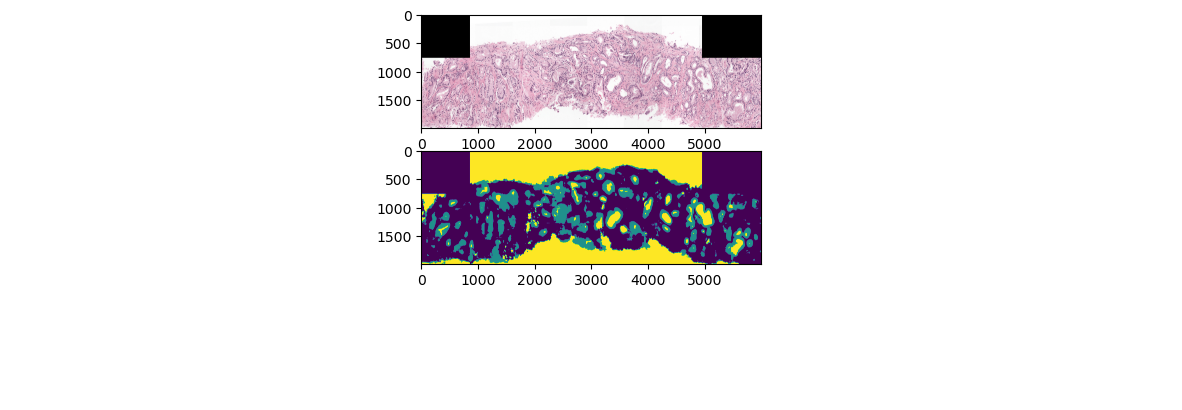

In [21]:
## Visualise
fig, axes = plt.subplots(3, 1, figsize=(15, 5))
axes[0].imshow(img[0:2000,4000:10000])
axes[1].imshow(mask[0:2000,4000:10000])
axes[2].axis('off')
# axes[3].axis('off')
plt.show()
plt.close()

In [ ]:
############
## SHIFTS ##
############

## Tile coordinates
x_center = int(1000/(level+1))
y_center = int(1000/(level+1))
dx = dy = int(100/(level+1))
tile_coordinates = [[x_center, y_center] for _ in range(4)]
k = 0
for i in [-1, 1]:
    for j in [-1, 1]:
        tile_coordinates[k][0] = tile_coordinates[k][0] + i * dx
        tile_coordinates[k][1] = tile_coordinates[k][1] + j * dy        
        k += 1
k = 0
for i in [-1, 1]:
    for j in [-1, 1]:
        tile_coordinates[k][0] = tile_coordinates[k][0] - i * dx
        tile_coordinates[k][1] = tile_coordinates[k][1] - j * dy        
        k += 1
tile_coordinates = [tile_coordinates]

## Instantiate the dataset
dataset = WSIDatasetByInstance(
    wsi_path_list=wsi_paths,
    tile_coordinate_list=tile_coordinates,
    tile_size=tile_size,
    level=level
)

#
###